In [ ]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sys,platform,sklearn
print("Python:", sys.version.split()[0])
print("OS:",platform.platform())
print("numpy:",np.__version__)
print("pandas:",pd.__version__)
print(sns.__version__)
print("scikit-learn:",sklearn.__version__)


Python: 3.13.15
OS: Linux-6.6.122+-x86_64-with-glibc2.39
numpy: 2.1.3
pandas: 2.2.3
0.13.2
scikit-learn: 1.6.1


# **Importation des librairies**

In [ ]:
import numpy as np
import pandas as pd

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.metrics import roc_auc_score, brier_score_loss, roc_curve

import matplotlib.pyplot as plt
from pathlib import Path

In [ ]:
# Your Windows paths (edit if needed)
#DATA_PATH = Path(r"C:\Users\erico\Desktop\SEGLA\CANADA\PARA PROGRAMMES\CERTIFICATION\RISQUE CREDIT\IFRS9 RISK CREDI MOEDLLING IN- PYTHON\MODULE1\Donnée_application.csv")
#ARTIFACT_DIR = Path(r"C:\Users\erico\Desktop\SEGLA\CANADA\PARA PROGRAMMES\CERTIFICATION\RISQUE CREDIT\IFRS9 RISK CREDI MOEDLLING IN- PYTHON\MODULE1")

# Fallback for this environment
#if not DATA_PATH.exists():
#    DATA_PATH = Path("/mnt/data/Donnée_application.csv")
#    ARTIFACT_DIR = Path("/mnt/data/IFRS9_PD_Clean")
#ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)

#print("Dataset:", DATA_PATH)
#print("Outputs:", ARTIFACT_DIR)

In [ ]:
#df = pd.read_csv(DATA_PATH)
#print("Shape:", df.shape)
#df.head(5)


# **Visualisation des données**

In [ ]:
data_app = pd.read_csv('Donnée_application.csv')
print("Shape:", data_app.shape)
data_app.head(5)


Shape: (5000, 20)


,loan_origination_date,report_date,default_date,loan_age_m,credit_utilization,dpd,internal_score,age,macro_gdp_growth,macro_unemployment,macro_interest_rate,LGD,EAD,default_flag,account_id,employment_status,marital_status,dependents,region,stage
0,10/25/2021,3/1/2024,NaN,29,0.42,99,551,36,4.33,4.51,3.36,0.405836,59524.80636,0,9449975,Employed,Single,3,West,3
1,6/11/2018,5/1/2022,8/10/2022,47,1.00,139,868,66,0.29,6.18,2.36,0.693087,145931.71780,1,6228566,Employed,Married,0,West,3
2,2/20/2021,8/1/2024,NaN,42,0.43,27,351,57,2.29,4.14,3.41,0.418884,33587.13655,0,3844180,Employed,Divorced,0,South,2
3,12/22/2017,9/1/2024,NaN,81,1.00,154,755,21,2.50,6.88,3.23,0.700000,148398.19620,0,6931161,Employed,Married,3,South,3
4,12/4/2021,7/1/2022,10/25/2022,7,0.73,119,802,38,3.31,4.32,2.90,0.539792,129156.58160,1,2655016,Employed,Married,2,West,3


In [ ]:
data_app.describe()

,loan_age_m,credit_utilization,dpd,internal_score,age,macro_gdp_growth,macro_unemployment,macro_interest_rate,LGD,EAD,default_flag,account_id,dependents,stage
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5.000000e+03,5000.000000,5000.000000
mean,59.441400,0.675062,66.668800,604.113200,45.232400,1.985808,4.988148,3.002596,0.514533,106449.213376,0.468600,5.500156e+06,1.959800,2.412400
std,26.334952,0.332186,54.940233,173.398472,14.138004,1.020388,1.505023,0.504459,0.178920,53415.601038,0.499063,2.573993e+06,1.407757,0.635301
min,7.000000,0.000000,0.000000,300.000000,21.000000,-1.590000,-0.670000,1.250000,0.150000,2000.000000,0.000000,1.000917e+06,0.000000,1.000000
25%,38.000000,0.390000,3.000000,453.000000,33.000000,1.310000,3.970000,2.670000,0.362211,63023.621448,0.000000,3.273186e+06,1.000000,2.000000
50%,59.000000,0.770000,85.000000,609.000000,45.000000,1.980000,4.990000,3.000000,0.569923,117416.105250,0.000000,5.476448e+06,2.000000,2.000000
75%,80.000000,1.000000,117.000000,756.000000,57.000000,2.670000,5.990000,3.340000,0.685975,150045.635050,1.000000,7.700957e+06,3.000000,3.000000
max,119.000000,1.000000,180.000000,899.000000,69.000000,5.810000,10.280000,4.790000,0.700000,222547.658400,1.000000,9.998604e+06,4.000000,3.000000


## **Affichage des variables**

In [ ]:
data_app.columns = [c.strip().lower().replace(" ", "_") for c in data_app.columns]
data_app.columns.tolist()[:30]

['loan_origination_date',
 'report_date',
 'default_date',
 'loan_age_m',
 'credit_utilization',
 'dpd',
 'internal_score',
 'age',
 'macro_gdp_growth',
 'macro_unemployment',
 'macro_interest_rate',
 'lgd',
 'ead',
 'default_flag',
 'account_id',
 'employment_status',
 'marital_status',
 'dependents',
 'region',
 'stage']

### **Liste des variables d'alertes : client en defaut,....**

In [ ]:
Alertes = set()

# Nom des variables d'alertes
for col in ["stage", "dpd", "dpd_clip", "dpd_30plus", "default_date", "lgd", "ead"]:
    if col in data_app.columns:
        Alertes.add(col)

# Alertes à partir des models
for c in data_app.columns:
    low = c.lower()
    if any(x in low for x in ["arrears", "chargeoff", "collection", "writeoff", "status"]):
        Alertes.add(c)

print("liste des Alertes:", sorted(Alertes))

# Conservez une copie de DPD et STAGE
dpd_exists = "dpd" in data_app.columns
stage_exists = "stage" in data_app.columns

# Nous les écarterons après avoir appliqué le filtre de pré-défaut à l'étape suivante.

liste des Alertes: ['default_date', 'dpd', 'ead', 'employment_status', 'lgd', 'marital_status', 'stage']


# **Le Filte préalable au défaut**

In [ ]:
initial_n = len(data_app)

if stage_exists:
    data_app = data_app[data_app["stage"] != 3].copy()

if dpd_exists:
    data_app = data_app[data_app["dpd"].fillna(0) < 60].copy()

filtered_n = len(data_app)
print(f"Nombre de lignes de données retirées : {initial_n - filtered_n}")

# Ratrait des clients ayants avec des alertes
data_app = data_app.drop(columns=list(Alertes), errors="ignore").copy()
print("Nombre de variables apres le retrait des alertes :", len(data_app.columns))

Nombre de lignes de données retirées : 2677
Nombre de variables apres le retrait des alertes : 13


In [ ]:
data_app.describe()

,loan_age_m,credit_utilization,internal_score,age,macro_gdp_growth,macro_unemployment,macro_interest_rate,default_flag,account_id,dependents
count,2323.000000,2323.000000,2323.000000,2323.000000,2323.000000,2323.000000,2323.000000,2323.000000,2.323000e+03,2323.000000
mean,58.907017,0.580340,669.755919,44.950926,1.973896,4.892204,2.998020,0.281963,5.483664e+06,1.952217
std,26.580432,0.342716,158.097284,14.088230,1.044211,1.485680,0.500095,0.450052,2.588354e+06,1.391759
min,7.000000,0.000000,300.000000,21.000000,-1.590000,-0.670000,1.450000,0.000000,1.000917e+06,0.000000
25%,38.000000,0.260000,555.000000,33.000000,1.300000,3.870000,2.660000,0.000000,3.242436e+06,1.000000
50%,59.000000,0.580000,691.000000,45.000000,1.960000,4.940000,3.000000,0.000000,5.473447e+06,2.000000
75%,79.500000,0.980000,808.000000,57.000000,2.685000,5.870000,3.330000,1.000000,7.689350e+06,3.000000
max,119.000000,1.000000,899.000000,69.000000,5.810000,10.180000,4.790000,1.000000,9.997354e+06,4.000000


#**Traitement de la qualité des données**

In [ ]:
Cible = "default_flag"
if Cible not in data_app.columns:
    raise ValueError("Cible 'default_flag'non indentifié.")

# Nettoyage de la Cible
data_app[Cible] = data_app[Cible].astype(float).round().clip(0,1).astype(int)

# Supprimer les données avec Cible manquante
data_app = data_app[~data_app[Cible].isna()].copy()

# Insertion + Indicateur
for col in data_app.columns:
    if col == Cible:
        continue
    if pd.api.types.is_numeric_dtype(data_app[col]):
        miss = data_app[col].isna()
        if miss.any():
            data_app[f"{col}_miss"] = miss.astype(int)
            data_app[col] = data_app[col].fillna(data_app[col].median())
    else:
        miss = data_app[col].isna()
        if miss.any():
            data_app[f"{col}_miss"] = miss.astype(int)
            data_app[col] = data_app[col].fillna("UNK")

# Autres indications
if "internal_score" in data_app.columns and "score_rev" not in data_app.columns:
    data_app["score_rev"] = data_app["internal_score"]

base_util = None
for c in ["credit_utilization", "utilization"]:
    if c in data_app.columns:
        base_util = c; break
if base_util and "util_log" not in data_app.columns:
    data_app["util_log"] = np.log1p(np.clip(data_app[base_util], 0, 1000))

print("Nombre de lignes apres analyses de la qualité des données:", len(data_app))

Nombre de lignes apres analyses de la qualité des données: 2323


# **Création de la variable `age_months` et segmentation des données par cohortes d'âge.**

In [ ]:
# Creation de la variable age_months
age_candidates = ["loan_age_m","loan_age","mob","months_on_book","months_since_open","age_months","age_m","tenure_m","vintage_m"]
age_col = None
for c in age_candidates:
    if c in data_app.columns and pd.api.types.is_numeric_dtype(data_app[c]):
        age_col = c; break

if age_col is None and "loan_origination_date" in data_app.columns and "report_date" in data_app.columns:
    o = pd.to_datetime(data_app["loan_origination_date"], errors="coerce", infer_datetime_format=True)
    r = pd.to_datetime(data_app["report_date"], errors="coerce", infer_datetime_format=True)
    data_app["age_months"] = ((r.dt.year - o.dt.year) * 12 + (r.dt.month - o.dt.month)).astype(float)
    age_col = "age_months"

if age_col is None and "age" in data_app.columns and pd.api.types.is_numeric_dtype(data_app["age"]):
    data_app["age_months"] = (data_app["age"] * 12).astype(float)
    age_col = "age_months"

if age_col is None:
    raise ValueError("No usable age indicator found. Add a months-on-book column or date columns.")

if age_col != "age_months":
    data_app["age_months"] = data_app[age_col].astype(float)

# Quadratic + dummies
if "age2" not in data_app.columns:
    data_app["age2"] = np.square(data_app["age_months"])
data_app["age_6m"]   = (data_app["age_months"] <= 6).astype(int)
data_app["age_6_24"] = ((data_app["age_months"] > 6) & (data_app["age_months"] <= 24)).astype(int)
data_app["age_24p"]  = (data_app["age_months"] > 24).astype(int)

# split des echantillons
train = data_app[data_app["age_months"] <= 6].copy()
valid = data_app[(data_app["age_months"] > 6) & (data_app["age_months"] <= 24)].copy()
test  = data_app[data_app["age_months"] > 24].copy()

if min(len(train), len(valid), len(test)) == 0:
    q1, q2 = data_app["age_months"].quantile([0.33, 0.66])
    train = data_app[data_app["age_months"] <= q1].copy()
    valid = data_app[(data_app["age_months"] > q1) & (data_app["age_months"] <= q2)].copy()
    test  = data_app[data_app["age_months"] > q2].copy()

print("Split sizes:", len(train), len(valid), len(test))


Split sizes: 768 777 778


# **Sélection des caractéristiques simples et entraînement du modèle de régression logistique**

In [ ]:

Variables_candidate = [
    "score_rev", "util_log",
    "age2", "age_6m", "age_6_24", "age_24p",
    "macro_gdp_growth", "macro_unemployment", "macro_interest_rate"
]

features = [c for c in Variables_candidate if c in data_app.columns and pd.api.types.is_numeric_dtype(data_app[c])]
features += [c for c in data_app.columns if c.endswith("_miss") and pd.api.types.is_numeric_dtype(data_app[c])]

X_tr = train.loc[:, [c for c in features if c in train.columns]]
y_tr = train[Cible]
X_va = valid.loc[:, [c for c in features if c in valid.columns]]
y_va = valid[Cible]
X_te = test.loc[:,  [c for c in features if c in test.columns]]
y_te = test[Cible]

print("Les variables utilisées:", X_tr.columns.tolist())

base = Pipeline([("scaler", StandardScaler()),
                 ("logit", LogisticRegression(max_iter=200, solver="lbfgs", class_weight="balanced"))])
try:
    clf = CalibratedClassifierCV(estimator=base, cv=5, method="sigmoid")
except TypeError:
    clf = CalibratedClassifierCV(base_estimator=base, cv=5, method="sigmoid")
clf.fit(X_tr, y_tr)

pd_tr = clf.predict_proba(X_tr)[:, 1]
pd_va = clf.predict_proba(X_va)[:, 1]
pd_te = clf.predict_proba(X_te)[:, 1]

Les variables utilisées: ['score_rev', 'util_log', 'age2', 'age_6m', 'age_6_24', 'age_24p', 'macro_gdp_growth', 'macro_unemployment', 'macro_interest_rate']


# **Évaluation de l'AUC, du KS, du score de Brier**

In [ ]:
# KS helper (inline, simple)
fpr_tr, tpr_tr, _ = roc_curve(y_tr, pd_tr)
fpr_va, tpr_va, _ = roc_curve(y_va, pd_va)
fpr_te, tpr_te, _ = roc_curve(y_te, pd_te)
ks_tr = float(np.max(np.abs(tpr_tr - fpr_tr)))
ks_va = float(np.max(np.abs(tpr_va - fpr_va)))
ks_te = float(np.max(np.abs(tpr_te - fpr_te)))

metrics = {
    "Indicateur d'entraienement": {"auc": float(np.max(np.abs(roc_auc_score(y_tr, pd_tr)))), "ks": ks_tr, "brier": float(np.max(np.abs(brier_score_loss(y_tr, pd_tr))))},
    "Indicateur de validation": {"auc": float(np.max(np.abs(roc_auc_score(y_va, pd_va)))), "ks": ks_va, "brier": float(np.max(np.abs(brier_score_loss(y_va, pd_va))))},
    "Indicateur de test":  {"auc": float(np.max(np.abs(roc_auc_score(y_te, pd_te)))), "ks": ks_te, "brier": float(np.max(np.abs(brier_score_loss(y_te, pd_te))))},
}
metrics

{"Indicateur d'entraienement": {'auc': 0.7219587053571428,
  'ks': 0.36186974789915966,
  'brier': 0.1807032198681416},
 'Indicateur de validation': {'auc': 0.6702089674051656,
  'ks': 0.25853127709860063,
  'brier': 0.28727435950498076},
 'Indicateur de test': {'auc': 0.6069037572835041,
  'ks': 0.1667912397026321,
  'brier': 0.5755821555053635}}

## **La courbe de calibration**

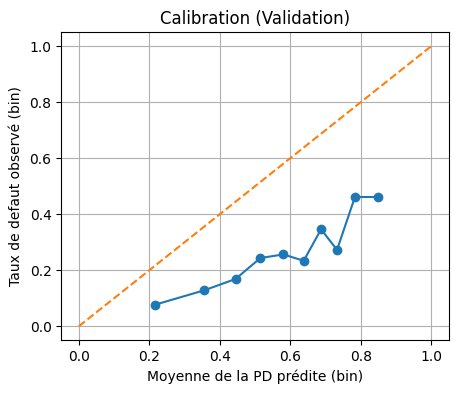

In [ ]:
frac_pos, mean_pred = calibration_curve(y_va, pd_va, n_bins=10, strategy="quantile")
plt.figure(figsize=(5,4))
plt.plot(mean_pred, frac_pos, marker="o")
plt.plot([0,1],[0,1],"--")
plt.xlabel("Moyenne de la PD prédite (bin)")
plt.ylabel("Taux de defaut observé (bin)")
plt.title("Calibration (Validation)")
plt.grid(True)
plt.show()


# **Équation de score (logit)**

In [ ]:
# Ajuster un pipeline de base (non calibré) pour extraire les coefficients, puis les reconvertir dans l'espace des variables d'origine.

base_for_eq = Pipeline([("scaler", StandardScaler()),
                        ("logit", LogisticRegression(max_iter=200, solver="lbfgs", class_weight="balanced"))])
base_for_eq.fit(X_tr, y_tr)

scaler = base_for_eq.named_steps["scaler"]
logit  = base_for_eq.named_steps["logit"]

coef_scaled = logit.coef_.ravel()
intercept_scaled = float(logit.intercept_[0])
means = scaler.mean_
scales = scaler.scale_

beta = coef_scaled / scales
intercept = intercept_scaled - np.sum(coef_scaled * means / scales)
equation = "logit(PD_12m) = " + " ".join([f"{intercept:.6f}"] + [f"+({b:.6f}*{f})" for b, f in zip(beta, X_tr.columns)])

print(equation)

# Attribuer des scores aux segments et calculer une ECL simple (illustration uniquement)
train_out = train.copy(); train_out["pd_12m_cal"] = pd_tr
valid_out = valid.copy(); valid_out["pd_12m_cal"] = pd_va
test_out  = test.copy();  test_out["pd_12m_cal"]  = pd_te

# Pas de LGD/EAD parmi les variables ; définition de valeurs par défaut à titre d'illustration.
for out in [train_out, valid_out, test_out]:
    if "lgd" not in out.columns: out["lgd"] = 0.45
    if "ead" not in out.columns: out["ead"] = 1.0
    out["ecl_12m"] = out["pd_12m_cal"].clip(0,1) * out["lgd"] * out["ead"]


logit(PD_12m) = -1.148960 +(-0.002745*score_rev) +(3.075219*util_log) +(0.000744*age2) +(0.000000*age_6m) +(0.434469*age_6_24) +(-0.434469*age_24p) +(0.034888*macro_gdp_growth) +(0.176969*macro_unemployment) +(-0.005375*macro_interest_rate)
